In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path(sys.prefix).parent
%cd {PROJECT_ROOT}

/home/younes/younes/Projects/Python/barid_internship


In [2]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [3]:
import polars as pl
import altair as alt
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from functools import partial
from fpppy.utils import plot_series, plot_series_stacked, plot_diagnostics
from utilsforecast.plotting import plot_series as plot_series_utils
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, rmsse, rmae, spis, nd
from coreforecast.scalers import boxcox, inv_boxcox, boxcox_lambda
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.utils import aggregate
from hierarchicalforecast.methods import BottomUp, TopDown, MinTrace
from utilsforecast.feature_engineering import trend, fourier, pipeline
from typing import Callable, Literal, Any, Mapping, Optional, Iterable, Sequence
from polars._typing import IntoExpr
from neuralforecast import NeuralForecast
from neuralforecast.models import MLP, BiTCN, LSTM, NHITS
from neuralforecast.auto import AutoNHITS, AutoMLP, AutoBiTCN, AutoLSTM
from neuralforecast.losses.pytorch import DistributionLoss, MAE
from neuralforecast.utils import PredictionIntervals

# import calendar

# from scipy.stats import pearsonr
# from plotly import express as px
# from pathlib import Path
# from itertools import chain
from datetime import date, timedelta
from itertools import product

import importlib
import lib
import read_data

importlib.reload(lib)

cfg = pl.Config()
cfg.set_tbl_width_chars(10000)
cfg.set_fmt_str_lengths(100)
cfg.set_tbl_cols(-1)
cfg.set_tbl_rows(10)

alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

In [4]:
gregorian_year_days = int(365.25)
gregorian_year_weeks = int(gregorian_year_days / 7)
hijri_year_days = int(354.37)
hijri_year_weeks = 51

In [5]:
cabs_inter = set(read_data.read_smi_envoisbyproduitintern_many()["codeenvoi_"])

In [6]:
fields = (
    pl.read_parquet("data/cab_dfs/fields.parquet")
    .filter(Etat="V")
    .filter(pl.col("Cab").is_in(cabs_inter))
    .filter(pl.col("Date_depot").ge(pl.date(2023, 1, 1)))
    .cast({"Id": pl.String})
    .sort("Date_depot")
    .rename({"Poids_global_en_KG": "weight_kg"})
    .drop_nulls("weight_kg")
)

In [7]:
importlib.reload(lib)
base_df = (
    fields
    # .pipe(lib.top_n_or_other, "Centre_Agence_depot", 10, "other_agence")
    # .pipe(lib.top_n_or_other, "Destination", 10, "other_dist")
    .pipe(lib.top_n_or_other, "Centre_Agence_depot", 10)
    .pipe(lib.top_n_or_other, "Destination", 10)
    .with_columns(total=pl.lit("total"))
    .pipe(
        lib.aggregate_by_date,
        freq="7d",
        value_col="weight_kg",
        date_col="Date_depot",
        total_col="total_weight_kg",
        count_col="count",
        mean_col="mean_weight_kg",
        std_col="std_weight_kg",
        # extra_cols=lib.make_relative_hist_cols(
        #     "weight_kg", list(range(32)) + [np.inf], "sum"
        # ),
        group_cols=["Centre_Agence_depot", "Destination", "total"],
    )
)

root_base_df = (
    fields
    .pipe(
        lib.aggregate_by_date,
        freq="7d",
        value_col="weight_kg",
        date_col="Date_depot",
        total_col="total_weight_kg",
        count_col="count",
        mean_col="mean_weight_kg",
        std_col="std_weight_kg",
        # extra_cols=lib.make_relative_hist_cols(
        #     "weight_kg", list(range(32)) + [np.inf], "sum"
        # ),
    )
)

# chart = (
#     alt.Chart(base_df)
#     .mark_line(point=True)
#     .encode(
#         x="Date_depot:T",
#         y=alt.Y("count:Q", scale=alt.Scale(zero=False)),
#         tooltip=["Date_depot:T"],
#     )
#     .properties(width=1100, title="Weekly Mean Weight")
# )
# chart

In [8]:
def transform_timeseries(
    df: pl.DataFrame,
    cols: IntoExpr | Iterable[IntoExpr] = "y",
) -> pl.DataFrame:
    cols_exprs = lib.as_exprs(cols)
    return df.with_columns([col.log1p() for col in cols_exprs])


def untransform_timeseries(
    df: pl.DataFrame,
    cols: IntoExpr | Iterable[IntoExpr] = pl.exclude("unique_id", "ds"),
) -> pl.DataFrame:
    cols_exprs = lib.as_exprs(cols)
    return df.with_columns([col.exp() - 1 for col in cols_exprs])


def calculate_max_n_windows(N, h, season_length, step_size):
    return (N - h - season_length - 1) // step_size


def fake_grouped_fc(
    root_fc: pl.DataFrame,
    grouped_Y_df: pl.DataFrame,
) -> pl.DataFrame:

    return root_fc.pipe(
        lib.complete_grid,
        dimensions={
            "unique_id": grouped_Y_df["unique_id"].unique(),
            "ds": root_fc["ds"].sort().unique(),
        },
        fill_value=0,
    )


def reconcile_forecast(
    root_fc: pd.DataFrame,
    Y_df: pl.DataFrame,
    S_df: pl.DataFrame,
    tags: dict[str, np.ndarray],
):
    raw_fc = pl.DataFrame(
        root_fc,
        schema_overrides={"ds": pl.Date},
    ).pipe(fake_grouped_fc, Y_df)

    recon = HierarchicalReconciliation(reconcilers=[TopDown("proportion_averages")])

    fc = recon.reconcile(
        Y_hat_df=raw_fc.to_pandas(),  # pyright: ignore[reportArgumentType]
        Y_df=Y_df.to_pandas(),  # pyright: ignore[reportArgumentType]
        S_df=S_df.to_pandas(),  # pyright: ignore[reportArgumentType]
        tags=tags,
    )

    return pl.DataFrame(fc)


def unnest_grouped_unique_id(
    df: pl.DataFrame,
    categories: Sequence[str],
) -> pl.DataFrame:
    return (
        df.filter(
            pl.col("unique_id").str.count_matches("/", literal=True) == len(categories)
        )
        .select(
            pl.col("unique_id")
            .str.extract_groups("^.+?/" + "/".join(len(categories) * ["(.+?)"]) + "$")
            .struct.rename_fields(categories)
            .struct.unnest(),
            pl.all(),
        )
        .drop("unique_id")
    )


def with_totals(
    df: pl.DataFrame,
    categories: Sequence[str],
    value_cols: IntoExpr | Iterable[IntoExpr] = pl.selectors.all(),
) -> pl.DataFrame:
    value_cols_exprs = lib.as_exprs(value_cols)

    return (
        pl.concat(
            df.with_columns(
                **{
                    col: pl.lit("all")
                    for col, use_all in zip(categories, mask)
                    if use_all
                }
            )
            for mask in product([True, False], repeat=len(categories))
        )
        .group_by(["ds", "Destination", "Centre_Agence_depot"], maintain_order=True)
        .agg(
            *[value_col.sum() for value_col in value_cols_exprs],
            # pl.selectors.exclude(value_cols_exprs).first(),  # requires the specialized Selector class, not any normal Expr
        )
    )


def sort_by_categories(df, categories):
    return df.sort(
        [
            pl.when(pl.col(category) == "all")
            .then(0)
            .when(pl.col(category) == "other")
            .then(2)
            .otherwise(1)
            for category in categories
        ]
        # + [pl.col(category) for category in categories]
    )

In [11]:
root_Y_df, root_X_df = (
    root_base_df.select(
        ds=pl.col("Date_depot"),
        y=pl.col("total_weight_kg"),
        unique_id=pl.lit("total"),
    )
    .pipe(transform_timeseries)
    .pipe(
        pipeline,
        [
            trend,
            # partial(fourier, season_length=52, k=5),
        ],
        "1w",
        4,
    )
)


levels: list[int] = [80, 95]
h = 4
# intervals_daily = ConformalIntervals(h=h, n_windows=min(10, len(df_daily) // h))
# intervals = ConformalIntervals(h=h, n_windows=10)
intervals = PredictionIntervals(step_size=1, n_windows=2)
cv_step_size = 10
# cv_n_windows_daily = calculate_max_n_windows(
#     len(df_daily), h, hijri_year_weeks, cv_step_size
# )
# cv_n_windows = calculate_max_n_windows(len(df), h, hijri_year_weeks, cv_step_size)
cv_n_windows = 1

In [16]:
sf = StatsForecast(
    freq="1w",
    n_jobs=-1,
    models=[
        SeasonalNaive(
            season_length=hijri_year_weeks,
            # prediction_intervals=intervals, # buggy
        ),
    ],
)

In [12]:
nf = NeuralForecast(
    models=[
        # AutoNHITS(
        #     h=4,
        # ),
        # AutoBiTCN(h=4),
        BiTCN(
            **{
                "h": 4,
                "hidden_size": 16,
                "dropout": 0.257496473259851,
                "learning_rate": 0.03308602267865399,
                "scaler_type": "robust",
                "max_steps": 1000,
                "batch_size": 128,
                "windows_batch_size": 512,
                "loss": MAE(),
                "random_seed": 10,
                "input_size": 20,
                "step_size": 4,
                "valid_loss": MAE(),
            }
        ),
        NHITS(
            **{
                "h": 4,
                "n_pool_kernel_size": [2, 2, 2],
                "n_freq_downsample": [24, 12, 1],
                "learning_rate": 0.00017565392237572106,
                "scaler_type": None,
                "max_steps": 1400.0,
                "batch_size": 256,
                "windows_batch_size": 1024,
                "loss": MAE(),
                "random_seed": 17,
                "input_size": 20,
                "step_size": 1,
                "valid_loss": MAE(),
            }
        ),
    ],
    freq="W",
)

Seed set to 10
Seed set to 17


In [13]:
nf.fit(
    df=root_Y_df.to_pandas(),
    # prediction_intervals=intervals,
)  # pyright: ignore[reportArgumentType]

GPU available: False, used: False


TPU available: False, using: 0 TPU cores

   | Name          | Type          | Params | Mode 
---------------------------------------------------------
0  | loss          | MAE           | 0      | train
1  | valid_loss    | MAE           | 0      | train
2  | padder_train  | ConstantPad1d | 0      | train
3  | scaler        | TemporalNorm  | 0      | train
4  | lin_hist      | Linear        | 32     | train
5  | drop_hist     | Dropout       | 0      | train
6  | net_bwd       | Sequential    | 5.4 K  | train
7  | drop_temporal | Dropout       | 0      | train
8  | temporal_lin1 | Linear        | 336    | train
9  | temporal_lin2 | Linear        | 68     | train
10 | output_lin    | Linear        | 17     | train
---------------------------------------------------------
5.8 K     Trainable params
0         Non-trainable params
5.8 K     Total params
0.023     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1400.0` reached.


In [14]:
root_fc = nf.predict(
    h=100,
    # level=levels,
)  # pyright: ignore[reportAssignmentType]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

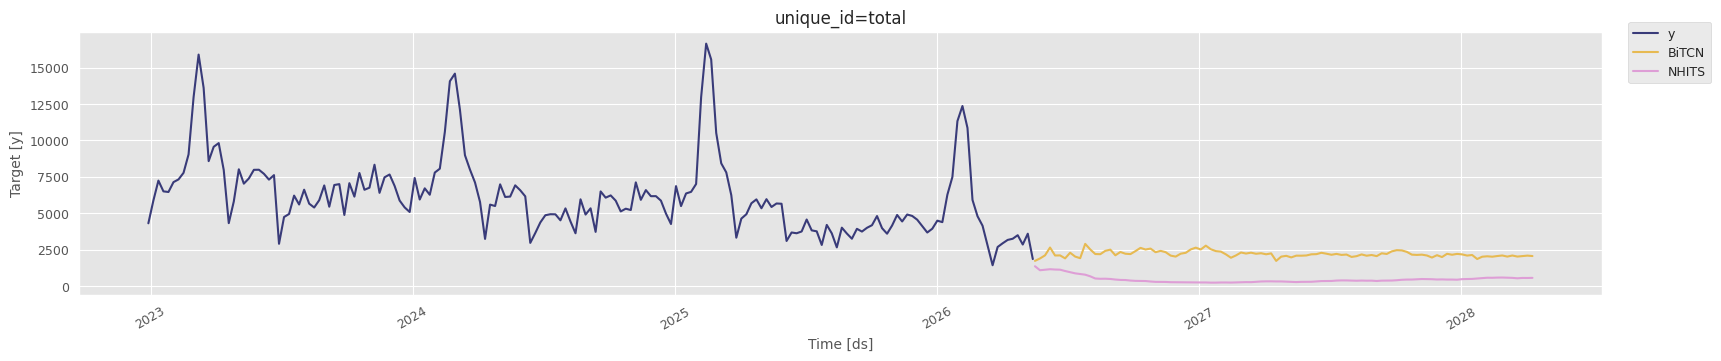

In [15]:
StatsForecast.plot(
    root_Y_df.pipe(untransform_timeseries).to_pandas(),
    pl.DataFrame(root_fc).pipe(untransform_timeseries).to_pandas(),
    # level=levels,  # pyright: ignore[reportArgumentType]
)

In [38]:
baseline_cv_df = sf.cross_validation(
    h=h,
    df=root_Y_df.to_pandas(),
    n_windows=1,
    step_size=cv_step_size,
    # level=levels,
)

cv_df = nf.cross_validation(
    h=h,
    df=root_Y_df.to_pandas(),
    n_windows=1,
    step_size=cv_step_size,
    # level=levels,
)

cv_df["SeasonalNaive"] = baseline_cv_df["SeasonalNaive"]

transformed_cv_df = pl.DataFrame(cv_df).pipe(
    untransform_timeseries,
    pl.exclude("unique_id", "ds", "cutoff"),
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

   | Name          | Type          | Params | Mode 
---------------------------------------------------------
0  | loss          | MAE           | 0      | train
1  | valid_loss    | MAE           | 0      | train
2  | padder_train  | ConstantPad1d | 0      | train
3  | scaler        | TemporalNorm  | 0      | train
4  | lin_hist      | Linear        | 32     | train
5  | drop_hist     | Dropout       | 0      | train
6  | net_bwd       | Sequential    | 5.4 K  | train
7  | drop_temporal | Dropout       | 0      | train
8  | temporal_lin1 | Linear        | 336    | train
9  | temporal_lin2 | Linear        | 68     | train
10 | output_lin    | Linear        | 17     | train
---------------------------------------------------------
5.8 K     Trainable params
0         Non-trainable params
5.8 K     Total params
0.023     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in e

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/younes/younes/Projects/Python/barid_internship/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1400.0` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

In [43]:
transformed_cv_df = transformed_cv_df.with_columns(
    neural_ensemble=(pl.col("BiTCN") + pl.col("NHITS")) / 2
)

cv_evaluation = evaluate(
    transformed_cv_df.to_pandas(),
    train_df=root_Y_df.to_pandas(),
    metrics=[
        partial(mase, seasonality=hijri_year_weeks),
        partial(rmae, baseline="SeasonalNaive"),
        spis,
        nd,
    ],
    # level=levels,
)
print(pl.DataFrame(cv_evaluation))

shape: (4, 7)
┌───────────┬─────────────────────┬────────────────────┬────────────┬────────────┬───────────────┬─────────────────┐
│ unique_id ┆ cutoff              ┆ metric             ┆ BiTCN      ┆ NHITS      ┆ SeasonalNaive ┆ neural_ensemble │
│ ---       ┆ ---                 ┆ ---                ┆ ---        ┆ ---        ┆ ---           ┆ ---             │
│ str       ┆ datetime[ms]        ┆ str                ┆ f64        ┆ f64        ┆ f64           ┆ f64             │
╞═══════════╪═════════════════════╪════════════════════╪════════════╪════════════╪═══════════════╪═════════════════╡
│ total     ┆ 2026-04-16 00:00:00 ┆ mase               ┆ 228.093866 ┆ 289.796279 ┆ 2116.059633   ┆ 237.952634      │
│ total     ┆ 2026-04-16 00:00:00 ┆ rmae_SeasonalNaive ┆ 0.107792   ┆ 0.136951   ┆ 1.0           ┆ 0.112451        │
│ total     ┆ 2026-04-16 00:00:00 ┆ spis               ┆ 33.487372  ┆ 42.54615   ┆ 310.667174    ┆ 34.934777       │
│ total     ┆ 2026-04-16 00:00:00 ┆ nd            

In [44]:
print(
    pl.DataFrame(cv_evaluation)
    .group_by("metric", "unique_id")
    .agg(pl.exclude("unique_id", "cutoff", "metric").pipe(lib.exp_weighted_mean, 3))
    # .unpivot(index="metric", variable_name="model", value_name="score")
    # .sort("score")
)

shape: (4, 6)
┌────────────────────┬───────────┬────────────┬────────────┬───────────────┬─────────────────┐
│ metric             ┆ unique_id ┆ BiTCN      ┆ NHITS      ┆ SeasonalNaive ┆ neural_ensemble │
│ ---                ┆ ---       ┆ ---        ┆ ---        ┆ ---           ┆ ---             │
│ str                ┆ str       ┆ f64        ┆ f64        ┆ f64           ┆ f64             │
╞════════════════════╪═══════════╪════════════╪════════════╪═══════════════╪═════════════════╡
│ rmae_SeasonalNaive ┆ total     ┆ 0.107792   ┆ 0.136951   ┆ 1.0           ┆ 0.112451        │
│ mase               ┆ total     ┆ 228.093866 ┆ 289.796279 ┆ 2116.059633   ┆ 237.952634      │
│ nd                 ┆ total     ┆ 0.115191   ┆ 0.146351   ┆ 1.068642      ┆ 0.12017         │
│ spis               ┆ total     ┆ 33.487372  ┆ 42.54615   ┆ 310.667174    ┆ 34.934777       │
└────────────────────┴───────────┴────────────┴────────────┴───────────────┴─────────────────┘


In [46]:
print(
    pl.DataFrame(cv_evaluation)
    .group_by("metric")
    .agg(pl.exclude("unique_id", "cutoff", "metric").mean())
    .unpivot(index="metric", variable_name="model", value_name="score")
    .sort("score")
)

shape: (16, 3)
┌────────────────────┬─────────────────┬─────────────┐
│ metric             ┆ model           ┆ score       │
│ ---                ┆ ---             ┆ ---         │
│ str                ┆ str             ┆ f64         │
╞════════════════════╪═════════════════╪═════════════╡
│ rmae_SeasonalNaive ┆ BiTCN           ┆ 0.107792    │
│ rmae_SeasonalNaive ┆ neural_ensemble ┆ 0.112451    │
│ nd                 ┆ BiTCN           ┆ 0.115191    │
│ nd                 ┆ neural_ensemble ┆ 0.12017     │
│ rmae_SeasonalNaive ┆ NHITS           ┆ 0.136951    │
│ …                  ┆ …               ┆ …           │
│ mase               ┆ BiTCN           ┆ 228.093866  │
│ mase               ┆ neural_ensemble ┆ 237.952634  │
│ mase               ┆ NHITS           ┆ 289.796279  │
│ spis               ┆ SeasonalNaive   ┆ 310.667174  │
│ mase               ┆ SeasonalNaive   ┆ 2116.059633 │
└────────────────────┴─────────────────┴─────────────┘


In [ ]:
# auto_nhits = nf.models[0]   # AutoNHITS instance

# best_config = auto_nhits.results.get_best_result().config
# print(best_config)

In [48]:
long_df = pl.DataFrame(cv_evaluation).unpivot(
    index=["unique_id", "cutoff", "metric"],
    on=pl.selectors.exclude(["unique_id", "cutoff", "metric"]),
    variable_name="model",
    value_name="value",
)

chart = (
    alt.Chart(long_df.to_pandas())
    .mark_line(point=True)
    .encode(
        x=alt.X("cutoff:T", title="Cutoff"),
        y=alt.Y("value:Q", title="RMAE"),
        color=alt.Color("model:N", title="Model"),
        tooltip=["cutoff:T", "model:N", "value:Q"],
    )
    .properties(width=800, height=400, title="RMAE over Cross-validation windows by model")
)

chart = lib.add_dropdown_filter(chart, long_df, "metric")

chart

alt.Chart(...)

In [ ]:
# pl.DataFrame(cv_evaluation).write_csv("results/neural_cv_evaluation.csv")

(raylet) The node with node id: 5b73a1814d8cc0c95b6a2e9064e23af170c20e59a8fd3504cb9389df and address: 192.168.31.220 and node name: 192.168.31.220 has been marked dead because the detector has missed too many heartbeats from it. This can happen when a 	(1) raylet crashes unexpectedly (OOM, etc.) 
	(2) raylet has lagging heartbeats due to slow network or busy workload.


[2026-06-24 12:42:49,359 E 135562 137190] core_worker.cc:475: :info_message: Attempting to recover 16 lost objects by resubmitting their tasks or setting a new primary location from existing copies. To disable object reconstruction, set @ray.remote(max_retries=0).
(raylet) [2026-06-24 12:42:50,077 C 137085 137085] (raylet) node_manager.cc:920: [Timeout] Exiting because this node manager has mistakenly been marked as dead by the GCS: GCS failed to check the health of this node for 5 times. This is likely because the machine or raylet has become overloaded.
(raylet) *** StackTrace Information ***
(raylet) /home/younes/younes/Projects/Python/barid_internship/.venv/lib/python3.13/site-packages/ray/core/src/ray/raylet/raylet(+0xfcceda) [0x61656461aeda] ray::operator<<()
(raylet) /home/younes/younes/Projects/Python/barid_internship/.venv/lib/python3.13/site-packages/ray/core/src/ray/raylet/raylet(+0xfcf4f9) [0x61656461d4f9] ray::RayLog::~RayLog()
(raylet) /home/younes/younes/Projects/Python/

(raylet) Raylet is terminated. Termination is unexpected. Possible reasons include: (1) SIGKILL by the user or system OOM killer, (2) Invalid memory access from Raylet causing SIGSEGV or SIGBUS, (3) Other termination signals. Last 20 lines of the Raylet logs:
    [2026-06-24 12:42:42,373 W 137085 137109] (raylet) memory_monitor_utils.cc:140: Got negative used memory for cgroup -1, setting it to zero
    [2026-06-24 12:42:47,379 W 137085 137109] (raylet) memory_monitor_utils.cc:140: Got negative used memory for cgroup -1, setting it to zero
    [2026-06-24 12:42:49,681 I 137085 137085] (raylet) accessor.cc:453: Received address and liveness notification for node, IsAlive = 0 node_id=5b73a1814d8cc0c95b6a2e9064e23af170c20e59a8fd3504cb9389df
    [2026-06-24 12:42:50,077 C 137085 137085] (raylet) node_manager.cc:920: [Timeout] Exiting because this node manager has mistakenly been marked as dead by the GCS: GCS failed to check the health of this node for 5 times. This is likely because the m

In [ ]:
# pl.DataFrame(root_fc).write_csv("results/neural_root_fc_h_100_weight.csv")

In [ ]:
# pl.DataFrame(root_fc).write_csv("results/neural_root_fc_h_4.csv")